In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Load your saved model and preprocessing pipeline artifacts
model = joblib.load('../models/best_xgb_model.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')



In [2]:
# 2. Load the engineered dataset to recreate the test split
df = pd.read_csv('../data/processed/fraud_data_engineered.csv')

# EMERGENCY PATCH: Add the placeholder if it's missing (matching your modeling notebook configuration)
if 'device_velocity_1h' not in df.columns:
    df['device_velocity_1h'] = 0.0

X = df.drop(columns=['class', 'user_id', 'device_id', 'signup_time', 'purchase_time', 'ip_address', 'ip_int'], errors='ignore')
y = df['class']

# Recreate the exact same test split using the stratify parameter
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)



In [3]:
# 3. Transform the test features using the loaded preprocessor pipeline
X_test_proc = preprocessor.transform(X_test)

# 4. Extract proper feature names for SHAP visualizations
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(['source', 'browser', 'sex', 'country']).tolist()
all_feature_names = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week'] + encoded_cat_names

# 5. Now sample your dataframe securely!
X_test_df = pd.DataFrame(X_test_proc, columns=all_feature_names).sample(500, random_state=42)

print("X_test_proc recreated and wrapped successfully!")


X_test_proc recreated and wrapped successfully!


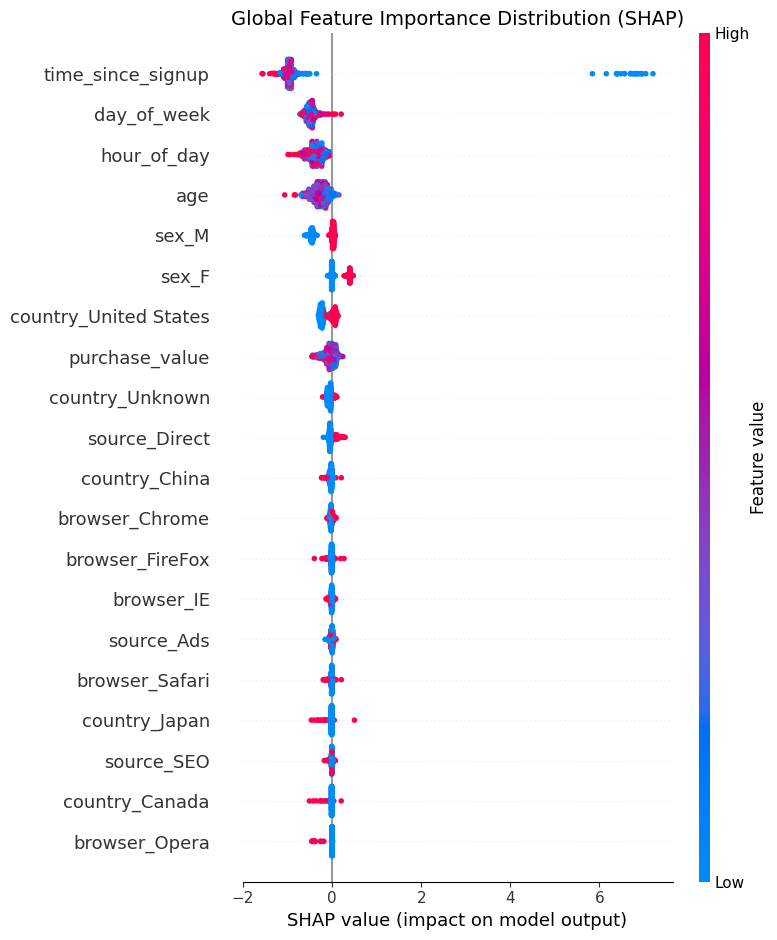

Generating Localized Instance Breakdown Map...


In [5]:
# Re-get exact transformed column names for interpretability maps
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(['source', 'browser', 'sex', 'country']).tolist()
all_feature_names = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week'] + encoded_cat_names

# Sample dynamic rows from test frame for SHAP processing
# (Using a sample size of 500 to accelerate runtime)
X_test_df = pd.DataFrame(X_test_proc, columns=all_feature_names).sample(500, random_state=42)

# Compute Tree SHAP Values
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_df)

# 1. Global Explanations: Summary Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("Global Feature Importance Distribution (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/shap_global_summary.png')
plt.show()

# 2. Local Explanations: Isolate individual rows (True Positive example index)
# Initialize JS for notebook visualization rendering
shap.initjs()

# Render localized force plot execution
print("Generating Localized Instance Breakdown Map...")
shap.plots.force(shap_values[0])